In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [2]:
data=pd.read_csv("kddcup99_csv.csv")

In [3]:
data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,0,tcp,http,SF,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal
494016,0,tcp,http,SF,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal
494017,0,tcp,http,SF,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal
494018,0,tcp,http,SF,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal


In [4]:
data.protocol_type = pd.factorize(data.protocol_type)[0] + 1

data.service = pd.factorize(data.service)[0] + 1

data.flag = pd.factorize(data.flag)[0] + 1

In [5]:
gb=data.groupby("label")

In [6]:
gb.size()

label
back                 2203
buffer_overflow        30
ftp_write               8
guess_passwd           53
imap                   12
ipsweep              1247
land                   21
loadmodule              9
multihop                7
neptune            107201
nmap                  231
normal              97277
perl                    3
phf                     4
pod                   264
portsweep            1040
rootkit                10
satan                1589
smurf              280790
spy                     2
teardrop              979
warezclient          1020
warezmaster            20
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  int64  
 2   service                      494020 non-null  int64  
 3   flag                         494020 non-null  int64  
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   land                         494020 non-null  int64  
 7   wrong_fragment               494020 non-null  int64  
 8   urgent                       494020 non-null  int64  
 9   hot                          494020 non-null  int64  
 10  num_failed_logins            494020 non-null  int64  
 11  logged_in                    494020 non-null  int64  
 12  lnum_compromised             494020 non-null  int64  
 13 

In [8]:
data_two = data.copy()

In [9]:
data_two

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,1,1,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal
1,0,1,1,1,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal
2,0,1,1,1,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
3,0,1,1,1,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
4,0,1,1,1,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,0,1,1,1,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal
494016,0,1,1,1,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal
494017,0,1,1,1,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal
494018,0,1,1,1,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal


In [10]:
data.label = pd.factorize(data.label)[0] + 1

In [11]:
data.describe()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
count,494020.000000,494020.000000,494020.000000,494020.000000,4.940200e+05,4.940200e+05,494020.000000,494020.000000,494020.000000,494020.000000,...,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000
mean,47.979400,2.189341,9.392393,1.835962,3.025616e+03,8.685308e+02,0.000045,0.006433,0.000014,0.034519,...,188.666052,0.753781,0.030906,0.601936,0.006684,0.176754,0.176443,0.058118,0.057412,4.932568
std,707.747185,0.960704,4.973786,1.579213,9.882191e+05,3.304003e+04,0.006673,0.134805,0.005510,0.782103,...,106.040205,0.410780,0.109259,0.481309,0.042133,0.380593,0.380920,0.230590,0.230141,2.297775
min,0.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,1.000000,10.000000,1.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
50%,0.000000,3.000000,10.000000,1.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
75%,0.000000,3.000000,11.000000,1.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
max,58329.000000,3.000000,66.000000,11.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23.000000


In [12]:
data_two

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,1,1,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal
1,0,1,1,1,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal
2,0,1,1,1,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
3,0,1,1,1,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
4,0,1,1,1,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,0,1,1,1,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal
494016,0,1,1,1,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal
494017,0,1,1,1,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal
494018,0,1,1,1,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal


In [13]:
y = data['label']

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(data, y, train_size=.7)

In [15]:
from sklearn.ensemble import RandomForestClassifier

feature_names = [f"feature {i}" for i in range(data.shape[1])]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, Y_train)
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

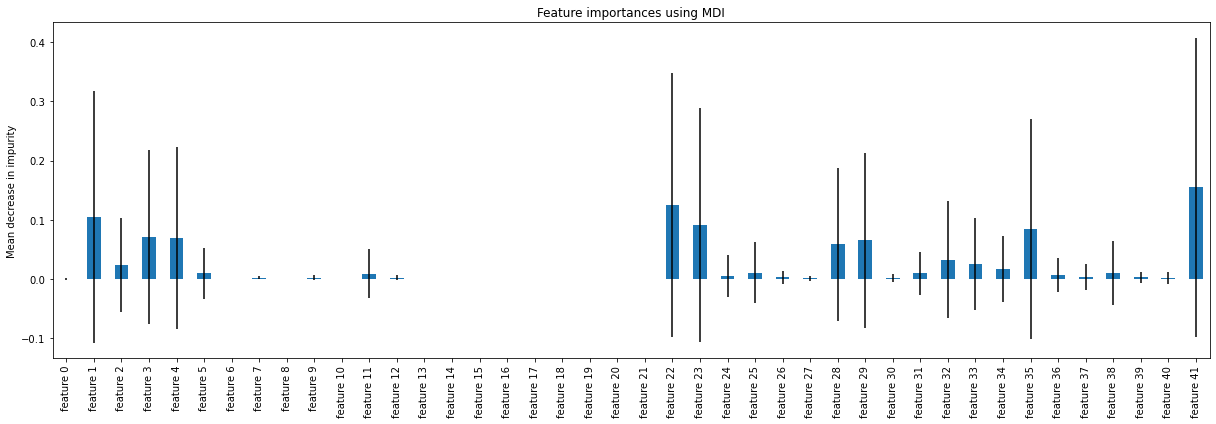

In [16]:
forest_importances = pd.Series(importances, index=feature_names)

#fig, ax = plt.subplots()
fig, ax = plt.subplots(figsize=(17, 6))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
#plt.show()

In [17]:
new_data = data.drop(['dst_host_serror_rate', 'srv_rerror_rate', 'rerror_rate', 'land', 'urgent', 'num_failed_logins', 'lnum_compromised', 'lroot_shell', 'lsu_attempted', 'lnum_root', 'lnum_file_creations', 'lnum_shells', 'lnum_file_creations', 'lnum_shells', 'lnum_access_files', 'lnum_outbound_cmds', 'is_host_login', 'is_guest_login'], axis=1, inplace=True)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  int64  
 2   service                      494020 non-null  int64  
 3   flag                         494020 non-null  int64  
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   wrong_fragment               494020 non-null  int64  
 7   hot                          494020 non-null  int64  
 8   logged_in                    494020 non-null  int64  
 9   count                        494020 non-null  int64  
 10  srv_count                    494020 non-null  int64  
 11  serror_rate                  494020 non-null  float64
 12  srv_serror_rate              494020 non-null  float64
 13 

In [19]:
y = data['label']

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(data, y, train_size=.7)

In [21]:
feature_names = [f"feature {i}" for i in range(data.shape[1])]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, Y_train)
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

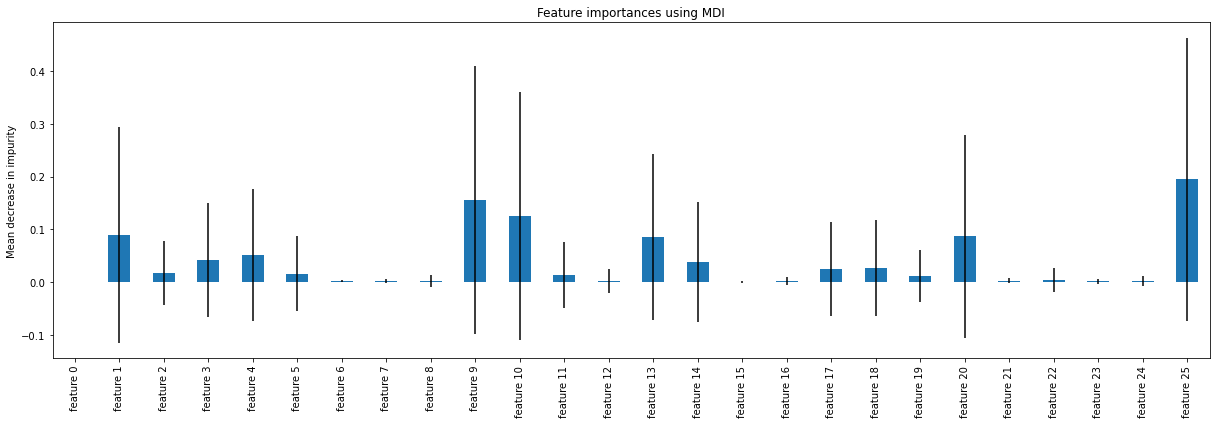

In [22]:
forest_importances = pd.Series(importances, index=feature_names)

#fig, ax = plt.subplots()
fig, ax = plt.subplots(figsize=(17, 6))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
#plt.show()

In [23]:
gb=data_two.groupby("label")

In [24]:
gb.size()

label
back                 2203
buffer_overflow        30
ftp_write               8
guess_passwd           53
imap                   12
ipsweep              1247
land                   21
loadmodule              9
multihop                7
neptune            107201
nmap                  231
normal              97277
perl                    3
phf                     4
pod                   264
portsweep            1040
rootkit                10
satan                1589
smurf              280790
spy                     2
teardrop              979
warezclient          1020
warezmaster            20
dtype: int64

In [25]:
gb.get_group("normal")

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,1,1,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal
1,0,1,1,1,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal
2,0,1,1,1,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
3,0,1,1,1,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
4,0,1,1,1,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,0,1,1,1,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal
494016,0,1,1,1,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal
494017,0,1,1,1,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal
494018,0,1,1,1,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal


In [26]:
result = gb.get_group("normal").append([gb.get_group("neptune"), gb.get_group("smurf"), gb.get_group("satan"), gb.get_group("back") ], ignore_index='True')


In [27]:
result


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,1,1,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.00,0.00,0.00,0.00,normal
1,0,1,1,1,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.00,0.00,0.00,0.00,normal
2,0,1,1,1,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.00,0.00,0.00,0.00,normal
3,0,1,1,1,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.00,0.00,0.00,0.00,normal
4,0,1,1,1,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489055,0,1,1,1,54540,8314,0,0,0,2,...,96,1.0,0.0,0.01,0.0,0.01,0.01,0.01,0.01,back
489056,0,1,1,1,54540,8314,0,0,0,2,...,97,1.0,0.0,0.01,0.0,0.01,0.01,0.01,0.01,back
489057,0,1,1,1,54540,8314,0,0,0,2,...,98,1.0,0.0,0.01,0.0,0.01,0.01,0.01,0.01,back
489058,0,1,1,1,54540,8314,0,0,0,2,...,99,1.0,0.0,0.01,0.0,0.01,0.01,0.01,0.01,back


In [28]:
result.label = pd.factorize(result.label)[0] + 1

In [29]:
#Spliting the dataset into groups according to the label attribute
new_gb = result.groupby("label")

In [30]:
new_gb.size()

label
1     97277
2    107201
3    280790
4      1589
5      2203
dtype: int64

In [31]:
target = result['label']

In [32]:
result

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,1,1,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.00,0.00,0.00,0.00,1
1,0,1,1,1,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.00,0.00,0.00,0.00,1
2,0,1,1,1,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.00,0.00,0.00,0.00,1
3,0,1,1,1,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.00,0.00,0.00,0.00,1
4,0,1,1,1,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.00,0.00,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489055,0,1,1,1,54540,8314,0,0,0,2,...,96,1.0,0.0,0.01,0.0,0.01,0.01,0.01,0.01,5
489056,0,1,1,1,54540,8314,0,0,0,2,...,97,1.0,0.0,0.01,0.0,0.01,0.01,0.01,0.01,5
489057,0,1,1,1,54540,8314,0,0,0,2,...,98,1.0,0.0,0.01,0.0,0.01,0.01,0.01,0.01,5
489058,0,1,1,1,54540,8314,0,0,0,2,...,99,1.0,0.0,0.01,0.0,0.01,0.01,0.01,0.01,5


In [33]:
target

0         1
1         1
2         1
3         1
4         1
         ..
489055    5
489056    5
489057    5
489058    5
489059    5
Name: label, Length: 489060, dtype: int64

In [34]:
#Oversampling
#ros = RandomOverSampler(random_state=42)

#X_res, y_res = ros.fit_resample(result, target)

In [35]:
#Undersampling
rus = RandomUnderSampler(random_state=42)

X_res, y_res = rus.fit_resample(result, target)

In [36]:
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1589, 2: 1589, 3: 1589, 4: 1589, 5: 1589})


In [37]:
X_res

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,1,1,200,563,0,0,0,0,...,255,1.00,0.00,0.12,0.03,0.00,0.02,0.00,0.00,1
1,0,1,1,1,167,1578,0,0,0,0,...,255,1.00,0.00,0.50,0.08,0.00,0.00,0.00,0.00,1
2,0,1,2,1,2030,332,0,0,0,0,...,170,0.71,0.05,0.01,0.01,0.00,0.00,0.00,0.00,1
3,0,1,1,1,339,2037,0,0,0,0,...,255,1.00,0.00,0.02,0.04,0.00,0.00,0.00,0.00,1
4,0,2,4,1,44,69,0,0,0,0,...,215,0.84,0.01,0.00,0.00,0.00,0.00,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7940,0,1,1,1,54540,8314,0,0,0,2,...,255,1.00,0.00,0.00,0.00,0.01,0.01,0.05,0.05,5
7941,0,1,1,1,54540,8314,0,0,0,2,...,40,1.00,0.00,0.03,0.00,0.03,0.03,0.03,0.03,5
7942,0,1,1,1,54540,8314,0,0,0,2,...,255,1.00,0.00,0.00,0.00,0.01,0.01,0.03,0.03,5
7943,0,1,1,1,54540,8314,0,0,0,2,...,93,1.00,0.00,0.01,0.00,0.01,0.01,0.01,0.01,5


In [38]:
gb_new_SMOTE = X_res.groupby("label")

In [39]:
gb_new_SMOTE.size()

label
1    1589
2    1589
3    1589
4    1589
5    1589
dtype: int64

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X_res, y_res, train_size=.7)

In [41]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [42]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [43]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [44]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [45]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))

Accuracy for SVM Test Data:                         0.6510067114093959
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.9828020134228188


In [46]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [47]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            0.7724362709027985
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.9892337735439605


In [48]:
### Decision Tree

In [49]:
cm_model_test=confusion_matrix(Y_test, clf_X_test_pred)

In [50]:
cm_model_test

array([[518,   0,   0,   0,   0],
       [  0, 486,   0,   0,   0],
       [  0,   0, 445,   0,   0],
       [  0,   0,   0, 459,   0],
       [  0,   0,   0,   0, 476]], dtype=int64)

In [51]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=["normal", "neptune", "smurf", "satan", "back" ])

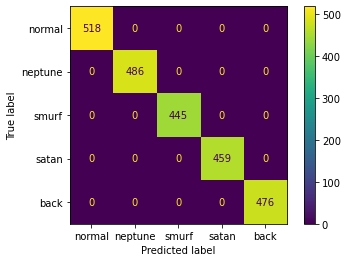

In [52]:
disp_model.plot() 

In [53]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000       518
           2      1.000     1.000     1.000       486
           3      1.000     1.000     1.000       445
           4      1.000     1.000     1.000       459
           5      1.000     1.000     1.000       476

    accuracy                          1.000      2384
   macro avg      1.000     1.000     1.000      2384
weighted avg      1.000     1.000     1.000      2384



In [54]:
### KNN

In [55]:
knn_model_test=confusion_matrix(Y_test, knn_X_test_pred)

In [56]:
knn_model_test

array([[509,   0,   2,   3,   4],
       [  0, 476,   0,  10,   0],
       [  0,   0, 445,   0,   0],
       [  2,  20,   0, 437,   0],
       [  0,   0,   0,   0, 476]], dtype=int64)

In [57]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=knn_model_test, display_labels=["normal", "neptune", "smurf", "satan", "back" ])

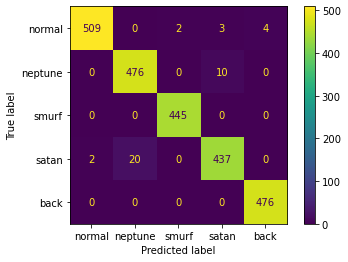

In [58]:
disp_model.plot()

In [59]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.996     0.983     0.989       518
           2      0.960     0.979     0.969       486
           3      0.996     1.000     0.998       445
           4      0.971     0.952     0.961       459
           5      0.992     1.000     0.996       476

    accuracy                          0.983      2384
   macro avg      0.983     0.983     0.983      2384
weighted avg      0.983     0.983     0.983      2384



In [60]:
### SVM

In [61]:
model_X_test=confusion_matrix(Y_test, model_X_test_pred)

In [62]:
model_X_test

array([[173,  79,  93, 169,   4],
       [  0,   0,   0, 486,   0],
       [  0,   0, 445,   0,   0],
       [  0,   0,   0, 459,   0],
       [  1,   0,   0,   0, 475]], dtype=int64)

In [63]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=model_X_test, display_labels=["normal", "neptune", "smurf", "satan", "back" ])

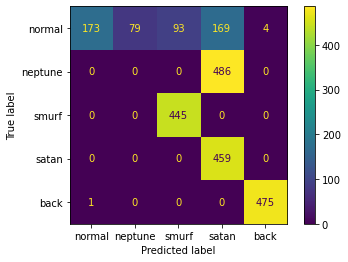

In [64]:
disp_model.plot()

In [65]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.994     0.334     0.500       518
           2      0.000     0.000     0.000       486
           3      0.827     1.000     0.905       445
           4      0.412     1.000     0.584       459
           5      0.992     0.998     0.995       476

    accuracy                          0.651      2384
   macro avg      0.645     0.666     0.597      2384
weighted avg      0.648     0.651     0.589      2384

